In [3]:
pip install ultralytics


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import kagglehub
path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")

print("Path to dataset files:", path)

c:\Users\conbi_g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\conbi_g\.cache\kagglehub\datasets\lorenzoarcioni\road-damage-dataset-potholes-cracks-and-manholes\versions\4


In [10]:
import os
for item in os.listdir(path):
    full=os.path.join(path,item)
    kind="DIR" if os.path.isdir(full) else "FILE"
    print(f"{kind} ->{item}")

DIR ->data


In [11]:
import os

data_path = os.path.join(path, "data")

for item in os.listdir(data_path):
    full = os.path.join(data_path, item)
    kind = "DIR " if os.path.isdir(full) else "FILE"
    print(f"{kind} -> {item}")


FILE -> annotations_coco.json
FILE -> COCO-conversion-script.py
DIR  -> images
DIR  -> labels
DIR  -> labels-YOLO
FILE -> README.md
FILE -> YOLO-conversion-script.py


In [13]:
import os
for item in os.listdir(data_path):
    full = os.path.join(data_path, item)
    if os.path.isdir(full):
        print(f"{item}/")
        # Peek inside
        for sub in os.listdir(full)[:5]:
            print(f"     └── {sub}")
    else:
        print(f"{item}")

annotations_coco.json
COCO-conversion-script.py
images/
     └── 20250216_164325.jpg
     └── 20250216_164521.jpg
     └── 20250216_164541.jpg
     └── 20250219_164649.jpg
     └── 20250219_164714.jpg
labels/
     └── 20250216_164325.txt
     └── 20250216_164521.txt
     └── 20250216_164541.txt
     └── 20250219_164649.txt
     └── 20250219_164714.txt
labels-YOLO/
     └── 20250216_164325.txt
     └── 20250216_164521.txt
     └── 20250216_164541.txt
     └── 20250219_164649.txt
     └── 20250219_164714.txt
README.md
YOLO-conversion-script.py


In [14]:
import matplotlib.pyplot as plt


In [15]:
pip install opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


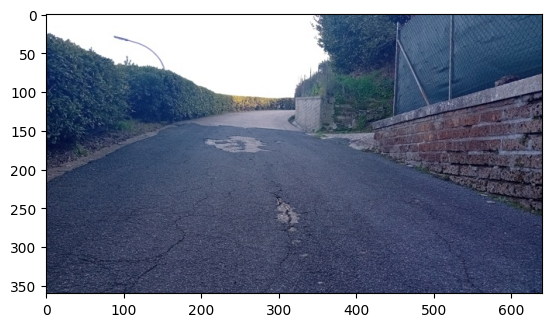

In [16]:
import cv2

image_path=os.path.join(data_path,"images","20250216_164521.jpg")

img=cv2.imread(image_path)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

In [17]:
label_path=image_path.replace("images","labels").replace(".jpg",".txt")
print(label_path)

C:\Users\conbi_g\.cache\kagglehub\datasets\lorenzoarcioni\road-damage-dataset-potholes-cracks-and-manholes\versions\4\data\labels\20250216_164521.txt


In [18]:
import os
count_txt=0

for roots,dirs,files in os.walk(data_path):
    for file in files:
        if file.endswith(".txt"):
            count_txt+=1
    
    
print(count_txt)

4018


In [24]:
import os
count_jpg=0

for roots,dirs,files in os.walk(data_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            count_jpg+=1
    
    
print(count_jpg)

2009


As we have gone through the dataset now we have to move the data and the label with 70% for training, 20% for validation and 10% for the Testing
